In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
spark = SparkSession.builder \
    .appName("UK Bus Delay Prediction") \
    .getOrCreate()

print("Spark Started Successfully!")

Spark Started Successfully!


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [5]:
stops = spark.read.csv(
    "file:///C:/bigdata/stops.txt",
    header=True,
    inferSchema=True
)

routes = spark.read.csv(
    "file:///C:/bigdata/routes.txt",
    header=True,
    inferSchema=True
)

trips = spark.read.csv(
    "file:///C:/bigdata/trips.txt",
    header=True,
    inferSchema=True
)

stop_times = spark.read.csv(
    "file:///C:/bigdata/stop_times.txt",
    header=True,
    inferSchema=True
)

agency = spark.read.csv(
    "file:///C:/bigdata/agency.txt",
    header=True,
    inferSchema=True
)

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [6]:
stops.show(5)

routes.show(5)

trips.show(5)

stop_times.show(5)

+------------+---------+----------------+-----------------+--------------------+-------------------+-------------+--------------+-------------+
|     stop_id|stop_code|       stop_name|         stop_lat|            stop_lon|wheelchair_boarding|location_type|parent_station|platform_code|
+------------+---------+----------------+-----------------+--------------------+-------------------+-------------+--------------+-------------+
|0500HFENS002| CMBDPADW|  Chequer Street|52.29866634479469|-0.07298550827900555|                  0|            0|          NULL|         NULL|
| 43000686302| nwmjdpjd|      Forge Road|         52.56891|            -2.04445|                  0|            0|          NULL|         NULL|
| 2000G503137| wocdatma|Lydiate Ash Road|        52.375432|           -2.045078|                  0|            0|          NULL|         NULL|
|5510AWA12874|  breapmg|     Iron Bridge|     51.614486576|        -3.662408445|                  0|            0|          NULL|       

In [7]:
stop_times_sample = stop_times.sample(False, 0.001, seed=42)
trips_sample = trips.sample(False, 0.01, seed=42)

print("Stop Times Sample:", stop_times_sample.count())
print("Trips Sample:", trips_sample.count())

Stop Times Sample: 55829
Trips Sample: 14712


In [8]:
bus_data = stop_times_sample.join(
    trips_sample,
    on="trip_id",
    how="inner"
)

bus_data = bus_data.join(
    routes,
    on="route_id",
    how="inner"
)

print("Sample datasets merged successfully!")

Sample datasets merged successfully!


In [9]:
bus_data.show(5)

+--------+--------------------+------------+--------------+------------+-------------+-------------+-----------+-------------+-------------------+---------+----------+--------------------+------------+--------------------+--------------------+---------------------+--------------------+---------+----------------+---------------+----------+
|route_id|             trip_id|arrival_time|departure_time|     stop_id|stop_sequence|stop_headsign|pickup_type|drop_off_type|shape_dist_traveled|timepoint|service_id|       trip_headsign|direction_id|            block_id|            shape_id|wheelchair_accessible|vehicle_journey_code|agency_id|route_short_name|route_long_name|route_type|
+--------+--------------------+------------+--------------+------------+-------------+-------------+-----------+-------------+-------------------+---------+----------+--------------------+------------+--------------------+--------------------+---------------------+--------------------+---------+----------------+-----

In [10]:
print("Stops:", stops.count())

print("Routes:", routes.count())

print("Trips:", trips.count())

print("Stop Times:", stop_times.count())

print("Agency:", agency.count())

Stops: 310270
Routes: 12808
Trips: 1460615
Stop Times: 55549196
Agency: 633


In [11]:
from pyspark.sql.functions import col, count, when

for df, name in [
    (stops, "Stops"),
    (routes, "Routes"),
    (trips, "Trips"),
    (stop_times, "Stop Times"),
    (agency, "Agency")
]:
    print(f"\n{name}")
    df.select([
        count(when(col(c).isNull(), c)).alias(c)
        for c in df.columns
    ]).show()


Stops
+-------+---------+---------+--------+--------+-------------------+-------------+--------------+-------------+
|stop_id|stop_code|stop_name|stop_lat|stop_lon|wheelchair_boarding|location_type|parent_station|platform_code|
+-------+---------+---------+--------+--------+-------------------+-------------+--------------+-------------+
|      0|     5687|        0|       0|       0|                  0|            0|        306953|       307329|
+-------+---------+---------+--------+--------+-------------------+-------------+--------------+-------------+


Routes
+--------+---------+----------------+---------------+----------+
|route_id|agency_id|route_short_name|route_long_name|route_type|
+--------+---------+----------------+---------------+----------+
|       0|        0|               0|          12808|         0|
+--------+---------+----------------+---------------+----------+


Trips
+--------+----------+-------+-------------+------------+--------+--------+---------------------+

In [12]:
# Count duplicates before removal
print("Stops duplicates:", stops.count() - stops.dropDuplicates().count())
print("Routes duplicates:", routes.count() - routes.dropDuplicates().count())
print("Trips duplicates:", trips.count() - trips.dropDuplicates().count())
print("Stop Times duplicates:", stop_times.count() - stop_times.dropDuplicates().count())
print("Agency duplicates:", agency.count() - agency.dropDuplicates().count())

# Remove duplicates
stops = stops.dropDuplicates()
routes = routes.dropDuplicates()
trips = trips.dropDuplicates()
stop_times = stop_times.dropDuplicates()
agency = agency.dropDuplicates()

print("Duplicate records removed successfully.")

Stops duplicates: 0
Routes duplicates: 0
Trips duplicates: 0
Stop Times duplicates: 0
Agency duplicates: 0
Duplicate records removed successfully.


In [13]:
print("Merged Records:", bus_data.count())
print("Number of Columns:", len(bus_data.columns))

Merged Records: 551
Number of Columns: 22


In [14]:
from pyspark.sql.functions import hour, to_timestamp

# Convert departure_time to timestamp
bus_data = bus_data.withColumn(
    "departure_timestamp",
    to_timestamp("departure_time", "HH:mm:ss")
)

# Extract departure hour
bus_data = bus_data.withColumn(
    "departure_hour",
    hour("departure_timestamp")
)

bus_data.select(
    "departure_time",
    "departure_hour"
).show(10)

+--------------+--------------+
|departure_time|departure_hour|
+--------------+--------------+
|      18:52:00|            18|
|      22:01:46|            22|
|      13:51:00|            13|
|      23:20:00|            23|
|      12:06:00|            12|
|      16:19:00|            16|
|      07:58:00|             7|
|      12:32:00|            12|
|      17:44:00|            17|
|      18:02:27|            18|
+--------------+--------------+
only showing top 10 rows



In [15]:
from pyspark.sql.functions import when

bus_data = bus_data.withColumn(
    "target",
    when(bus_data.stop_sequence > 20, 1).otherwise(0)
)

bus_data.select(
    "stop_sequence",
    "target"
).show(10)

+-------------+------+
|stop_sequence|target|
+-------------+------+
|           87|     1|
|           68|     1|
|            9|     0|
|           25|     1|
|           21|     1|
|            7|     0|
|           36|     1|
|           42|     1|
|           13|     0|
|           16|     0|
+-------------+------+
only showing top 10 rows



In [16]:
bus_data.select(
    "departure_hour",
    "route_type",
    "direction_id",
    "stop_sequence",
    "wheelchair_accessible",
    "target"
).show(10)

+--------------+----------+------------+-------------+---------------------+------+
|departure_hour|route_type|direction_id|stop_sequence|wheelchair_accessible|target|
+--------------+----------+------------+-------------+---------------------+------+
|            18|         3|           0|           87|                    0|     1|
|            22|         3|           1|           68|                    0|     1|
|            13|         3|           0|            9|                    0|     0|
|            23|         1|           0|           25|                    1|     1|
|            12|         3|           0|           21|                    0|     1|
|            16|         3|           1|            7|                    0|     0|
|             7|         3|           1|           36|                    0|     1|
|            12|         3|           0|           42|                    0|     1|
|            17|         3|           0|           13|                    0|

In [17]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "departure_hour",
        "route_type",
        "direction_id",
        "stop_sequence",
        "wheelchair_accessible"
    ],
    outputCol="features"
)

ml_data = assembler.transform(bus_data)

ml_data.select("features", "target").show(5, truncate=False)

+-----------------------+------+
|features               |target|
+-----------------------+------+
|[18.0,3.0,0.0,87.0,0.0]|1     |
|[22.0,3.0,1.0,68.0,0.0]|1     |
|[13.0,3.0,0.0,9.0,0.0] |0     |
|[23.0,1.0,0.0,25.0,1.0]|1     |
|[12.0,3.0,0.0,21.0,0.0]|1     |
+-----------------------+------+
only showing top 5 rows



In [18]:
from pyspark.sql.functions import col

ml_input = bus_data.select(
    "departure_hour",
    "route_type",
    "direction_id",
    "stop_sequence",
    "wheelchair_accessible",
    "target"
).dropna()

print("Rows after removing nulls:", ml_input.count())

Rows after removing nulls: 544


In [19]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "departure_hour",
        "route_type",
        "direction_id",
        "stop_sequence",
        "wheelchair_accessible"
    ],
    outputCol="features"
)

ml_data = assembler.transform(ml_input)

ml_data.select("features", "target").show(5, truncate=False)

+-----------------------+------+
|features               |target|
+-----------------------+------+
|[18.0,3.0,0.0,87.0,0.0]|1     |
|[22.0,3.0,1.0,68.0,0.0]|1     |
|[13.0,3.0,0.0,9.0,0.0] |0     |
|[23.0,1.0,0.0,25.0,1.0]|1     |
|[12.0,3.0,0.0,21.0,0.0]|1     |
+-----------------------+------+
only showing top 5 rows



In [20]:
train_data, test_data = ml_data.randomSplit([0.8, 0.2], seed=42)

print("Training Records:", train_data.count())
print("Testing Records:", test_data.count())

Training Records: 432
Testing Records: 112


In [21]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="target"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)

lr_predictions.select(
    "prediction",
    "target",
    "probability"
).show(5, truncate=False)

+----------+------+--------------------------+
|prediction|target|probability               |
+----------+------+--------------------------+
|0.0       |0     |[1.0,0.0]                 |
|1.0       |1     |[8.46405305868942E-46,1.0]|
|0.0       |0     |[1.0,0.0]                 |
|1.0       |1     |[0.0,1.0]                 |
|0.0       |0     |[1.0,0.0]                 |
+----------+------+--------------------------+
only showing top 5 rows



In [22]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="target",
    predictionCol="prediction",
    metricName="accuracy"
)

lr_accuracy = evaluator.evaluate(lr_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 1.0


In [23]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    labelCol="target",
    featuresCol="features"
)

dt_model = dt.fit(train_data)

dt_predictions = dt_model.transform(test_data)

dt_predictions.select(
    "prediction",
    "target",
    "probability"
).show(5, truncate=False)

+----------+------+-----------+
|prediction|target|probability|
+----------+------+-----------+
|0.0       |0     |[1.0,0.0]  |
|1.0       |1     |[0.0,1.0]  |
|0.0       |0     |[1.0,0.0]  |
|1.0       |1     |[0.0,1.0]  |
|0.0       |0     |[1.0,0.0]  |
+----------+------+-----------+
only showing top 5 rows



In [24]:
dt_accuracy = evaluator.evaluate(dt_predictions)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


In [25]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="target",
    featuresCol="features",
    numTrees=20,
    seed=42
)

rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)

rf_predictions.select(
    "prediction",
    "target",
    "probability"
).show(5, truncate=False)

+----------+------+----------------------------------------+
|prediction|target|probability                             |
+----------+------+----------------------------------------+
|0.0       |0     |[0.9181818181818182,0.08181818181818182]|
|1.0       |1     |[0.0,1.0]                               |
|0.0       |0     |[1.0,0.0]                               |
|1.0       |1     |[0.0,1.0]                               |
|0.0       |0     |[1.0,0.0]                               |
+----------+------+----------------------------------------+
only showing top 5 rows



In [26]:
rf_accuracy = evaluator.evaluate(rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [27]:
print("Logistic Regression Accuracy:", lr_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0
Random Forest Accuracy: 1.0


In [28]:
print("Number of Partitions:", bus_data.rdd.getNumPartitions())

print("Total Records:", bus_data.count())

bus_data.printSchema()

Number of Partitions: 36
Total Records: 551
root
 |-- route_id: integer (nullable = true)
 |-- trip_id: string (nullable = true)
 |-- arrival_time: string (nullable = true)
 |-- departure_time: string (nullable = true)
 |-- stop_id: string (nullable = true)
 |-- stop_sequence: integer (nullable = true)
 |-- stop_headsign: string (nullable = true)
 |-- pickup_type: integer (nullable = true)
 |-- drop_off_type: integer (nullable = true)
 |-- shape_dist_traveled: string (nullable = true)
 |-- timepoint: integer (nullable = true)
 |-- service_id: integer (nullable = true)
 |-- trip_headsign: string (nullable = true)
 |-- direction_id: integer (nullable = true)
 |-- block_id: string (nullable = true)
 |-- shape_id: string (nullable = true)
 |-- wheelchair_accessible: integer (nullable = true)
 |-- vehicle_journey_code: string (nullable = true)
 |-- agency_id: string (nullable = true)
 |-- route_short_name: string (nullable = true)
 |-- route_long_name: string (nullable = true)
 |-- route_ty

In [29]:
bus_data.cache()

print("Dataset Cached Successfully")

Dataset Cached Successfully


In [30]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

metrics = ["accuracy", "weightedPrecision", "weightedRecall", "f1"]

for metric in metrics:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="target",
        predictionCol="prediction",
        metricName=metric
    )

    score = evaluator.evaluate(rf_predictions)

    print(metric, ":", score)

accuracy : 1.0
weightedPrecision : 1.0
weightedRecall : 1.0
f1 : 1.0


In [31]:
rf_predictions.groupBy("target", "prediction").count().show()

+------+----------+-----+
|target|prediction|count|
+------+----------+-----+
|     0|       0.0|   63|
|     1|       1.0|   49|
+------+----------+-----+



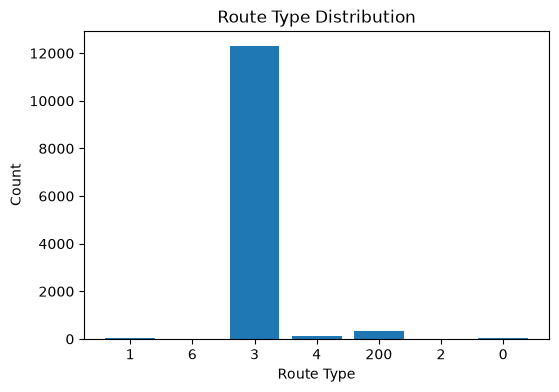

In [32]:
route_counts = routes.groupBy("route_type").count().toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(route_counts["route_type"].astype(str), route_counts["count"])
plt.title("Route Type Distribution")
plt.xlabel("Route Type")
plt.ylabel("Count")
plt.show()

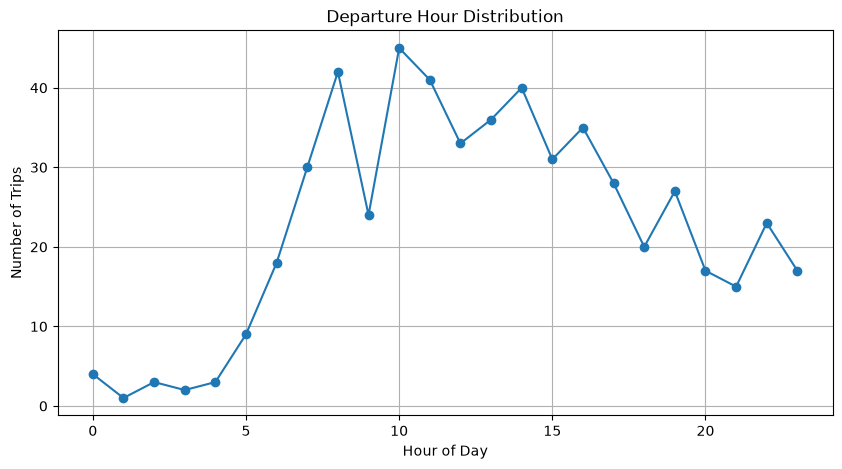

In [33]:
hour_counts = bus_data.groupBy("departure_hour").count().orderBy("departure_hour").toPandas()

plt.figure(figsize=(10,5))
plt.plot(hour_counts["departure_hour"], hour_counts["count"], marker="o")
plt.title("Departure Hour Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

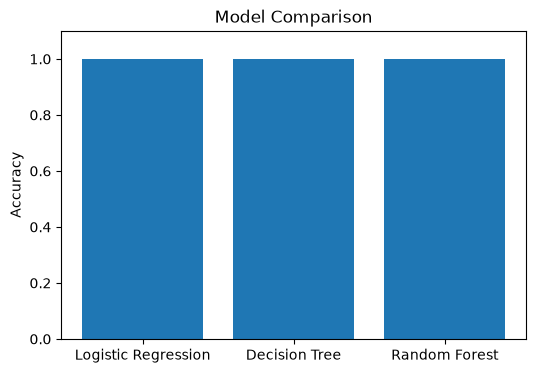

In [34]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [1.0, 1.0, 1.0]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()